In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

NOTEBOOK_DIR = Path().resolve()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

print("Loading preprocessed dataset...")
df = pd.read_parquet(PROCESSED_DIR / "04_preprocessed.parquet")

print(f"Shape: {df.shape}")
print(f"Target distribution: {Counter(df['TARGET'])}")
print(f"Default rate: {df['TARGET'].mean()*100:.2f}%")
print("\nLoaded successfully!")

Loading preprocessed dataset...
Shape: (307511, 253)
Target distribution: Counter({0: 282686, 1: 24825})
Default rate: 8.07%

Loaded successfully!


In [2]:
print("=" * 50)
print("TRAIN/TEST SPLIT")
print("=" * 50)

# Separate features and target
X = df.drop(columns=["TARGET", "SK_ID_CURR"])
y = df["TARGET"]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

# Split BEFORE SMOTE — never apply SMOTE to test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # maintain class ratio in both splits
)

print(f"\nTrain size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")
print(f"\nTrain target distribution:")
print(f"  Repaid    (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Defaulted (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTest target distribution:")
print(f"  Repaid    (0): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Defaulted (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")

TRAIN/TEST SPLIT
Features shape: (307511, 251)
Target shape:   (307511,)

Train size: 246,008 rows
Test size:  61,503 rows

Train target distribution:
  Repaid    (0): 226,148 (91.9%)
  Defaulted (1): 19,860 (8.1%)

Test target distribution:
  Repaid    (0): 56,538 (91.9%)
  Defaulted (1): 4,965 (8.1%)


In [3]:
print("=" * 50)
print("APPLYING SMOTE")
print("=" * 50)

print("Before SMOTE:")
print(f"  Class 0: {(y_train==0).sum():,}")
print(f"  Class 1: {(y_train==1).sum():,}")
print(f"  Ratio:   {(y_train==0).sum()/(y_train==1).sum():.1f}:1")

print("\nApplying SMOTE (this may take 2-3 minutes)...")

smote = SMOTE(
    sampling_strategy=0.3,  # make minority 30% of majority
    random_state=42,
    k_neighbors=5,
    n_jobs=-1
)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Class 0: {(y_train_smote==0).sum():,}")
print(f"  Class 1: {(y_train_smote==1).sum():,}")
print(f"  Ratio:   {(y_train_smote==0).sum()/(y_train_smote==1).sum():.1f}:1")
print(f"\nNew training size: {X_train_smote.shape[0]:,} rows")
print(f"Synthetic samples added: {X_train_smote.shape[0] - X_train.shape[0]:,}")

APPLYING SMOTE
Before SMOTE:
  Class 0: 226,148
  Class 1: 19,860
  Ratio:   11.4:1

Applying SMOTE (this may take 2-3 minutes)...

After SMOTE:
  Class 0: 226,148
  Class 1: 67,844
  Ratio:   3.3:1

New training size: 293,992 rows
Synthetic samples added: 47,984


VISUALIZING CLASS BALANCE


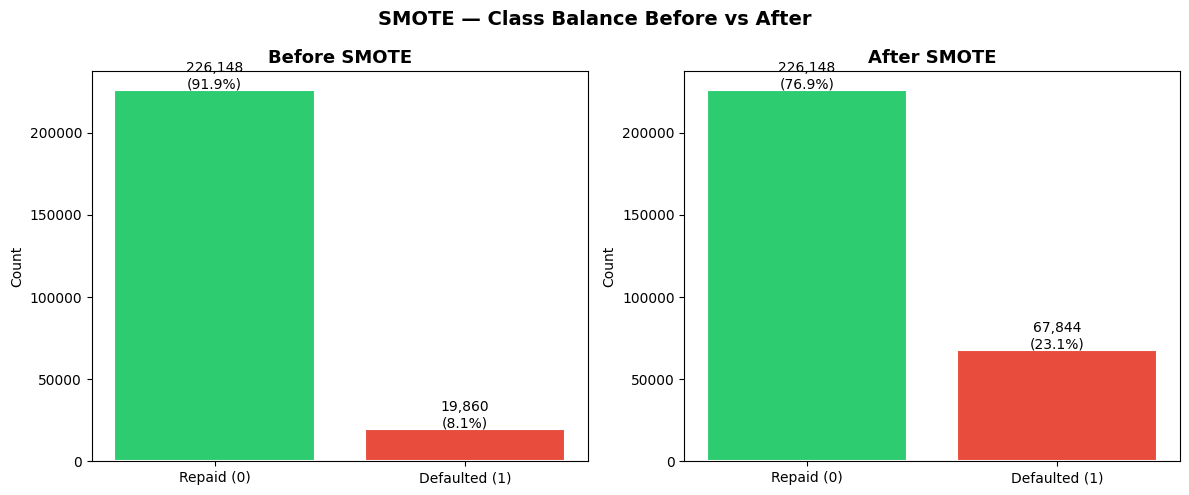

Plot saved!


In [4]:
print("=" * 50)
print("VISUALIZING CLASS BALANCE")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
before_counts = [( y_train==0).sum(), (y_train==1).sum()]
axes[0].bar(["Repaid (0)", "Defaulted (1)"],
            before_counts,
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white", linewidth=1.5)
axes[0].set_title("Before SMOTE", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(before_counts):
    axes[0].text(i, v + 1000, f"{v:,}\n({v/sum(before_counts)*100:.1f}%)",
                 ha="center", fontsize=10)

# After SMOTE
after_counts = [(y_train_smote==0).sum(), (y_train_smote==1).sum()]
axes[1].bar(["Repaid (0)", "Defaulted (1)"],
            after_counts,
            color=["#2ecc71", "#e74c3c"],
            edgecolor="white", linewidth=1.5)
axes[1].set_title("After SMOTE", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")
for i, v in enumerate(after_counts):
    axes[1].text(i, v + 1000, f"{v:,}\n({v/sum(after_counts)*100:.1f}%)",
                 ha="center", fontsize=10)

plt.suptitle("SMOTE — Class Balance Before vs After",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROCESSED_DIR / "10_smote_balance.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved!")

In [6]:
print("=" * 50)
print("SAVING ALL SPLITS")
print("=" * 50)

# Save feature matrices as parquet
X_train_smote_df = pd.DataFrame(X_train_smote, columns=X.columns)
X_test_df = pd.DataFrame(X_test.values, columns=X.columns)

X_train_smote_df.to_parquet(PROCESSED_DIR / "X_train.parquet", index=False)
X_test_df.to_parquet(PROCESSED_DIR / "X_test.parquet", index=False)

# Save target arrays as CSV (Series doesn't support parquet in older pandas)
pd.DataFrame({"TARGET": y_train_smote}).to_csv(
    PROCESSED_DIR / "y_train.csv", index=False)
pd.DataFrame({"TARGET": y_test.values}).to_csv(
    PROCESSED_DIR / "y_test.csv", index=False)

print(f"X_train (SMOTE): {X_train_smote_df.shape}")
print(f"X_test:          {X_test_df.shape}")
print(f"y_train (SMOTE): {len(y_train_smote):,}")
print(f"y_test:          {len(y_test):,}")

print("\nFiles saved:")
for f in sorted(PROCESSED_DIR.iterdir()):
    if f.suffix in [".parquet", ".csv", ".png"]:
        print(f"  {f.name:<40} {f.stat().st_size/1024**2:.1f} MB")

print("\nSMOTE complete — data ready for modeling!")

SAVING ALL SPLITS
X_train (SMOTE): (293992, 251)
X_test:          (61503, 251)
y_train (SMOTE): 293,992
y_test:          61,503

Files saved:
  01_class_imbalance.png                   0.1 MB
  02_feature_engineered.parquet            66.0 MB
  02_missing_values.png                    0.2 MB
  03_financial_distributions.png           0.1 MB
  03_time_series_features.parquet          91.3 MB
  04_age_employment.png                    0.1 MB
  04_preprocessed.parquet                  95.4 MB
  05_correlations.png                      0.2 MB
  06_categorical_analysis.png              0.2 MB
  07_new_features_correlation.png          0.1 MB
  08_timeseries_correlation.png            0.1 MB
  09_final_dataset_overview.png            0.1 MB
  10_smote_balance.png                     0.1 MB
  X_test.parquet                           20.8 MB
  X_train.parquet                          133.4 MB
  y_test.csv                               0.2 MB
  y_train.csv                              0.8 MB

S

In [7]:
print("=" * 60)
print("PHASE 2 COMPLETE — FULL SUMMARY")
print("=" * 60)

print(f"""
DATA PIPELINE COMPLETED
-----------------------
Raw data:         307,511 rows × 122 features
After engineering: 307,511 rows × 253 features
After encoding:   307,511 rows × 253 features
Missing values:   0 (all imputed)

TRAIN/TEST SPLIT
----------------
X_train (SMOTE): 293,992 rows × 251 features
X_test:           61,503 rows × 251 features
y_train (SMOTE): 293,992 labels (3.3:1 ratio)
y_test:           61,503 labels (11.4:1 ratio — real world)

FILES READY FOR MODELING
------------------------
X_train.parquet   133.4 MB
X_test.parquet     20.8 MB
y_train.csv         0.8 MB
y_test.csv          0.2 MB

NEXT STEP → Phase 3: Model Building
  • XGBoost default predictor + SHAP
  • FinBERT sentiment engine
  • LSTM risk forecaster
  • Calibrated ensemble scorer
""")

PHASE 2 COMPLETE — FULL SUMMARY

DATA PIPELINE COMPLETED
-----------------------
Raw data:         307,511 rows × 122 features
After engineering: 307,511 rows × 253 features
After encoding:   307,511 rows × 253 features
Missing values:   0 (all imputed)

TRAIN/TEST SPLIT
----------------
X_train (SMOTE): 293,992 rows × 251 features
X_test:           61,503 rows × 251 features
y_train (SMOTE): 293,992 labels (3.3:1 ratio)
y_test:           61,503 labels (11.4:1 ratio — real world)

FILES READY FOR MODELING
------------------------
X_train.parquet   133.4 MB
X_test.parquet     20.8 MB
y_train.csv         0.8 MB
y_test.csv          0.2 MB

NEXT STEP → Phase 3: Model Building
  • XGBoost default predictor + SHAP
  • FinBERT sentiment engine
  • LSTM risk forecaster
  • Calibrated ensemble scorer

